<a href="https://colab.research.google.com/github/hsmu-jeongeun/machine-learning-practice/blob/main/250507_kmeans_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-means 알고리즘

## KMeans 클래스

In [1]:
!curl -L -o fruits_300.npy https://bit.ly/fruits_300

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   119  100   119    0     0    449      0 --:--:-- --:--:-- --:--:--   450
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2929k  100 2929k    0     0  2878k      0  0:00:01  0:00:01 --:--:-- 5956k


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import numpy as np

fruits = np.load("fruits_300.npy")

print(fruits.shape)

(300, 100, 100)


In [5]:
fruits_2d = fruits.reshape(-1, 100*100)

In [6]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [7]:
print(km.labels_)

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [8]:
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [9]:
import matplotlib.pyplot as plt


# 각 클러스터별 샘플 이미지들을 한번에 그려주는 함수
def draw_fruits(arr, ratio=1):
    n = len(arr)    # n : 샘플 개수
    # 한 줄에 10개씩 이미지를 그릴 수 있도록 rows 수 설정
    rows = int(np.ceil(n/10)) # ceil : 올림 함수
    # columns 수 설정 : 행이 1개 이면 열 개수는 샘플 개수이고 그렇지 않으면 10개
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

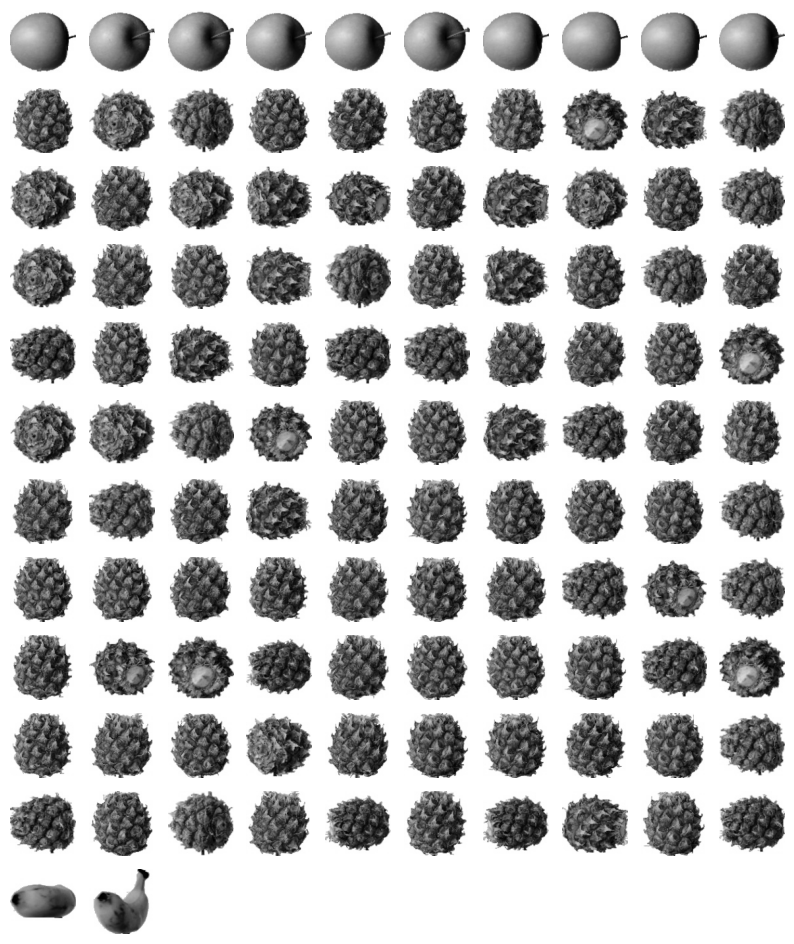

In [10]:
draw_fruits(fruits[km.labels_==0])

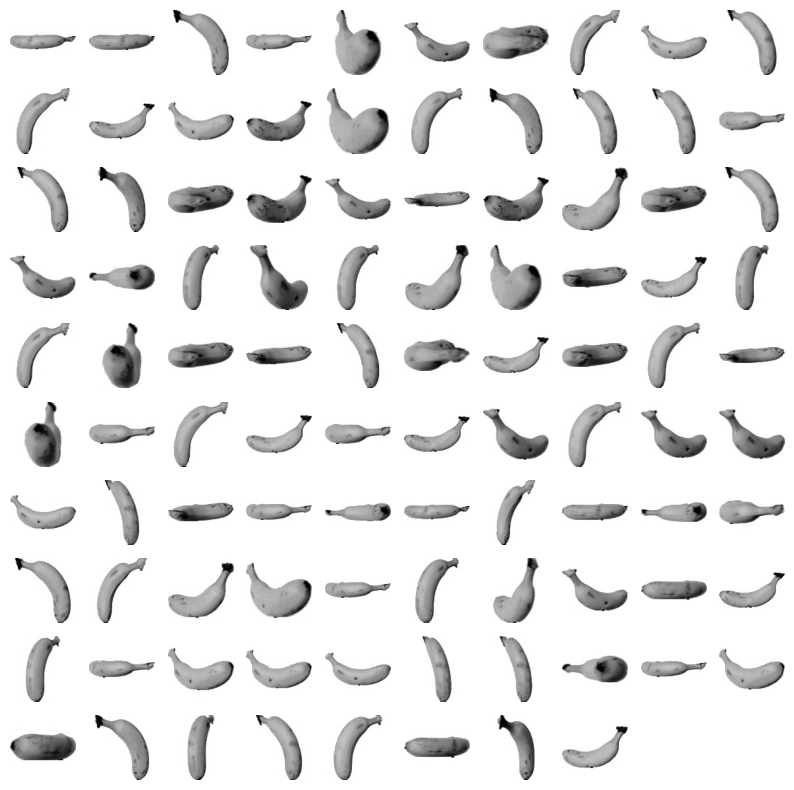

In [11]:
draw_fruits(fruits[km.labels_==1])

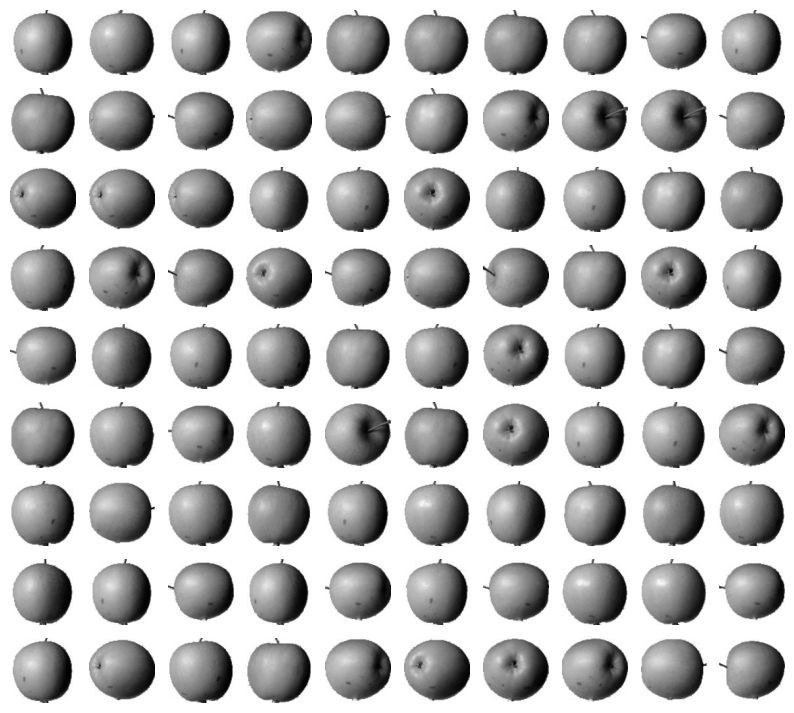

In [12]:
draw_fruits(fruits[km.labels_==2])

## 클러스터 중심

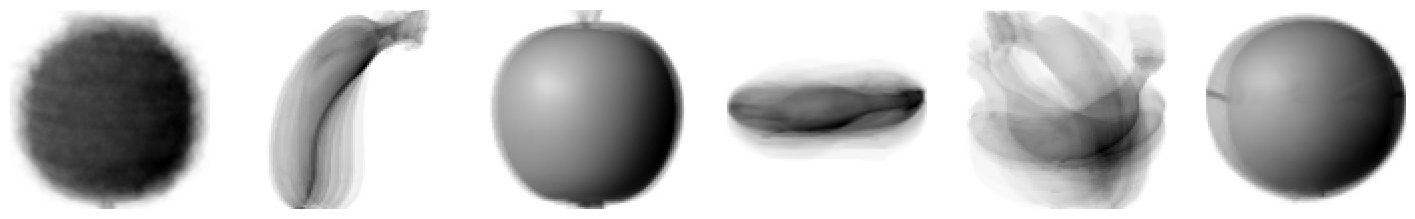

In [21]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3) # 클러스터 중심 이미지 그리기

In [14]:
print(km.transform(fruits_2d[100:101]))

[[3400.24197319 8837.37750892 5279.33763699]]


In [15]:
print(km.predict(fruits_2d[100:101]))

[0]


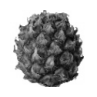

In [20]:
draw_fruits(fruits[100:101]) # 100번째 샘플 이미지 그리기

In [17]:
print(km.n_iter_)

4


## 최적의 k 찾기

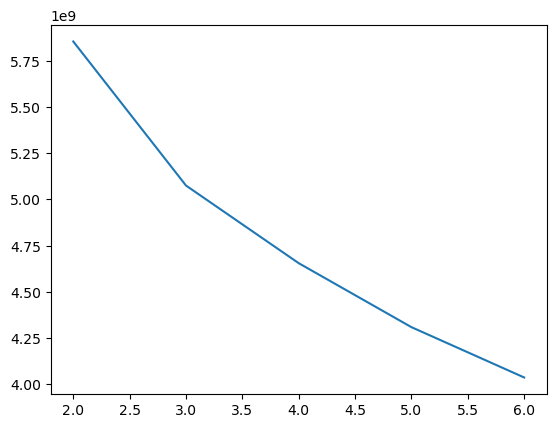

In [19]:
inertia = [] # 클러스터 개수에 따른 inertia 저장 리스트
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia)
plt.show()